# Phase 5 (Extension) — Data-Scarce Experiment

**Goal:** Show that GAN augmentation is most beneficial when real training data is LIMITED.

This notebook runs the same CNN-BiLSTM-Attention model at 5 different real-data fractions:
- 20%, 30%, 50%, 70%, 100% of available real training cycles

At each fraction, we compare:
- **Real-only** (only the scarce real data)
- **Augmented** (scarce real + GAN-generated synthetic data)

**Expected result:** At low fractions (20-30%), Augmented should clearly outperform Real-only.
This is the core claim of the paper — GAN augmentation helps when data is scarce.

**Input (same as Phase 5 main):**
- Phase 2 outputs: `nasa_gaf_images.npz`, `nasa_gaf_minmax.pkl`
- Phase 3 outputs: `cwdcgan_generator.keras`, `nasa_gaf_labels_with_split.csv`


In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
print("GPU:", tf.config.list_physical_devices("GPU"))

PHASE2_DIR  = "/kaggle/input/datasets/tasniaturin12/nasa-gaf-phase2-output"
PHASE3_DIR  = "/kaggle/input/datasets/tasniaturin12/nasa-gaf-phase3-output"
OUTPUT_DIR  = "/kaggle/working"
NOISE_DIM   = 100
NUM_CLASSES = 3
TARGET_LEN  = 128

images_array = np.load(os.path.join(PHASE2_DIR, "nasa_gaf_images.npz"))["images"]
with open(os.path.join(PHASE2_DIR, "nasa_gaf_minmax.pkl"), "rb") as f:
    gaf_minmax = pickle.load(f)
split_df  = pd.read_csv(os.path.join(PHASE3_DIR, "nasa_gaf_labels_with_split.csv"))
generator = tf.keras.models.load_model(os.path.join(PHASE3_DIR, "cwdcgan_generator.keras"))

print("Images:", images_array.shape)
print(split_df["split"].value_counts())


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


I0000 00:00:1783243255.666446      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783243255.669285      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Images: (2544, 128, 128, 3)
split
train       2028
excluded     387
test         129
Name: count, dtype: int64


## 2. Inverse-GAF + Signal Building (same as Phase 5 main)

In [2]:
def soh_to_bin(soh):
    if soh >= 85:   return 0
    elif soh >= 70: return 1
    else:           return 2

def inverse_gasf_diag(image_channel, min_val, max_val):
    diag   = np.clip(np.diag(image_channel), -1.0, 1.0)
    phi    = 0.5 * np.arccos(diag)
    scaled = np.cos(phi)
    return scaled * (max_val - min_val) + min_val

def image_to_signals(image, minmax):
    v = inverse_gasf_diag(image[:, :, 0], *minmax["voltage"])
    i = inverse_gasf_diag(image[:, :, 1], *minmax["current"])
    t = inverse_gasf_diag(image[:, :, 2], *minmax["temperature"])
    return np.stack([v, i, t], axis=-1)

def build_real_signals(df, images_arr, gaf_minmax):
    X, y = [], []
    for _, row in df.iterrows():
        battery = row["battery_id"]
        cycle   = int(row["source_cycle"])
        # find original index in images_array
        match = labels_df[
            (labels_df["battery_id"]   == battery) &
            (labels_df["source_cycle"] == cycle) &
            (~labels_df["is_augmented"])
        ]
        if len(match) == 0: continue
        img = images_arr[match.index[0]]
        if battery in gaf_minmax and cycle in gaf_minmax[battery]:
            minmax = gaf_minmax[battery][cycle]
        else:
            minmax = next(iter(gaf_minmax[battery].values()))
        X.append(image_to_signals(img, minmax))
        y.append(row["SOH_percent"])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Load original labels for index lookup
labels_df = pd.read_csv(os.path.join(PHASE2_DIR, "nasa_gaf_labels.csv"))

# Full real train + test sets (stratified split from Phase 5)
from sklearn.model_selection import StratifiedShuffleSplit

real_df = labels_df[~labels_df["is_augmented"]].copy().reset_index(drop=True)
real_df["soh_bin"] = real_df["SOH_percent"].apply(soh_to_bin)
real_df["strat_key"] = real_df["battery_id"] + "_" + real_df["soh_bin"].astype(str)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(sss.split(real_df, real_df["strat_key"]))

full_train_df = real_df.iloc[train_idx].copy()
test_df       = real_df.iloc[test_idx].copy()

print("Building test signals...")
X_full_train, y_full_train = build_real_signals(full_train_df, images_array, gaf_minmax)
X_test,       y_test       = build_real_signals(test_df,       images_array, gaf_minmax)

print(f"Full train: {X_full_train.shape} | Test: {X_test.shape}")
print(f"Train SOH: {y_full_train.min():.1f}% – {y_full_train.max():.1f}%")
print(f"Test  SOH: {y_test.min():.1f}% – {y_test.max():.1f}%")


Building test signals...
Full train: (508, 128, 3) | Test: (128, 128, 3)
Train SOH: 57.7% – 101.8%
Test  SOH: 57.9% – 100.7%


## 3. Generate Synthetic Signals (fixed pool, reused across all fractions)

In [3]:
# Global min/max from full real train
global_minmax = {
    "voltage":     (float(X_full_train[:,:,0].min()), float(X_full_train[:,:,0].max())),
    "current":     (float(X_full_train[:,:,1].min()), float(X_full_train[:,:,1].max())),
    "temperature": (float(X_full_train[:,:,2].min()), float(X_full_train[:,:,2].max())),
}

def generate_synthetic(generator, soh_targets, noise_dim=NOISE_DIM):
    X_syn = []
    for soh in soh_targets:
        noise = tf.random.normal([1, noise_dim])
        label = tf.constant([[soh_to_bin(float(soh))]])
        img   = generator([noise, label], training=False).numpy()[0]
        X_syn.append(image_to_signals(img, global_minmax))
    return np.array(X_syn, dtype=np.float32)

# Generate a large pool of synthetic samples (same size as full train)
# We will reuse this pool across experiments — only real data fraction changes
print(f"Generating {len(X_full_train)} synthetic signals (pool)...")
soh_targets_pool = np.random.choice(y_full_train, size=len(X_full_train), replace=True)
X_syn_pool = generate_synthetic(generator, soh_targets_pool)
y_syn_pool = soh_targets_pool.astype(np.float32)
print(f"Synthetic pool: {X_syn_pool.shape}")


Generating 508 synthetic signals (pool)...
Synthetic pool: (508, 128, 3)


## 4. CNN-BiLSTM-Attention Model

In [4]:
def attention_block(x):
    score   = layers.Dense(1, activation="tanh")(x)
    weight  = layers.Softmax(axis=1)(score)
    context = layers.Multiply()([x, weight])
    return layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(context)

def build_model(input_shape=(TARGET_LEN, 3)):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64,  3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)
    x = attention_block(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


## 5. Data-Scarce Experiment Loop

For each fraction of real training data:
1. Subsample real train cycles (stratified by SOH bin)
2. Take matching number of synthetic samples
3. Train Real-only model → evaluate on test
4. Train Augmented model → evaluate on test


In [5]:
FRACTIONS = [0.20, 0.30, 0.50, 0.70, 1.00]
EPOCHS    = 100
BATCH     = 32
SEEDS     = [42, 7, 13]   # run 3 seeds per fraction for stability

def run_experiment(X_tr, y_tr, X_te, y_te, soh_min, soh_max, seed=42):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    scaler = StandardScaler()
    n_tr, n_te = len(X_tr), len(X_te)
    scaler.fit(X_tr.reshape(n_tr, -1))

    X_tr_sc = scaler.transform(X_tr.reshape(n_tr,-1)).reshape(n_tr, TARGET_LEN, 3).astype(np.float32)
    X_te_sc = scaler.transform(X_te.reshape(n_te,-1)).reshape(n_te, TARGET_LEN, 3).astype(np.float32)

    def norm(y): return (y - soh_min) / (soh_max - soh_min + 1e-8)
    def denorm(yn): return yn * (soh_max - soh_min) + soh_min

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    model = build_model()
    model.fit(X_tr_sc, norm(y_tr), validation_split=0.15,
              epochs=EPOCHS, batch_size=BATCH, callbacks=cb, verbose=0)
    pred = denorm(model.predict(X_te_sc, verbose=0).flatten())

    return {
        "rmse": float(np.sqrt(mean_squared_error(y_te, pred))),
        "mae":  float(mean_absolute_error(y_te, pred)),
        "r2":   float(r2_score(y_te, pred)),
    }


results = []

for frac in FRACTIONS:
    n_real = max(10, int(len(X_full_train) * frac))
    print(f"\n{'='*55}")
    print(f"Fraction: {int(frac*100)}%  |  Real samples: {n_real}")
    print('='*55)

    # Stratified subsample of real train
    np.random.seed(42)
    # Keep SOH-bin proportions in the subsample
    sub_train_df = full_train_df.copy().reset_index(drop=True)
    sub_train_df["soh_bin"] = sub_train_df["SOH_percent"].apply(soh_to_bin)

    chosen_idx = []
    for bin_id in range(NUM_CLASSES):
        bin_rows = sub_train_df[sub_train_df["soh_bin"] == bin_id].index.tolist()
        n_take = max(1, round(len(bin_rows) * frac))
        chosen_idx += list(np.random.choice(bin_rows, min(n_take, len(bin_rows)), replace=False))

    X_real_sub = X_full_train[chosen_idx]
    y_real_sub = y_full_train[chosen_idx]

    # Matching synthetic (same count)
    n_syn = len(X_real_sub)
    X_syn_sub = X_syn_pool[:n_syn]
    y_syn_sub = y_syn_pool[:n_syn]

    X_aug_sub = np.concatenate([X_real_sub, X_syn_sub])
    y_aug_sub = np.concatenate([y_real_sub, y_syn_sub])

    soh_min = float(y_real_sub.min())
    soh_max = float(y_real_sub.max())

    # Run 3 seeds and average
    real_runs, aug_runs = [], []
    for seed in SEEDS:
        real_runs.append(run_experiment(X_real_sub, y_real_sub, X_test, y_test, soh_min, soh_max, seed))
        aug_runs.append(run_experiment(X_aug_sub,   y_aug_sub,  X_test, y_test, soh_min, soh_max, seed))

    def avg(runs, k): return round(np.mean([r[k] for r in runs]), 4)

    row = {
        "Fraction (%)":      int(frac * 100),
        "Real Samples":      n_real,
        "Real RMSE":         avg(real_runs, "rmse"),
        "Real MAE":          avg(real_runs, "mae"),
        "Real R2":           avg(real_runs, "r2"),
        "Aug RMSE":          avg(aug_runs,  "rmse"),
        "Aug MAE":           avg(aug_runs,  "mae"),
        "Aug R2":            avg(aug_runs,  "r2"),
        "RMSE Improvement":  round(avg(real_runs,"rmse") - avg(aug_runs,"rmse"), 4),
        "R2 Improvement":    round(avg(aug_runs,"r2") - avg(real_runs,"r2"), 4),
    }
    results.append(row)
    print(f"  Real-only:  RMSE={row['Real RMSE']:.4f}  R²={row['Real R2']:.4f}")
    print(f"  Augmented:  RMSE={row['Aug RMSE']:.4f}  R²={row['Aug R2']:.4f}")
    print(f"  RMSE improvement (positive = aug better): {row['RMSE Improvement']:.4f}")

results_df = pd.DataFrame(results)
print()
print(results_df[["Fraction (%)", "Real Samples", "Real RMSE", "Aug RMSE",
                   "Real R2", "Aug R2", "RMSE Improvement"]].to_string(index=False))



Fraction: 20%  |  Real samples: 101
  Real-only:  RMSE=4.3187  R²=0.8039
  Augmented:  RMSE=5.2988  R²=0.6133
  RMSE improvement (positive = aug better): -0.9801

Fraction: 30%  |  Real samples: 152
  Real-only:  RMSE=2.8611  R²=0.8976
  Augmented:  RMSE=5.3656  R²=0.6221
  RMSE improvement (positive = aug better): -2.5045

Fraction: 50%  |  Real samples: 254
  Real-only:  RMSE=2.6210  R²=0.8882
  Augmented:  RMSE=1.9392  R²=0.9607
  RMSE improvement (positive = aug better): 0.6818

Fraction: 70%  |  Real samples: 355
  Real-only:  RMSE=2.3289  R²=0.9056
  Augmented:  RMSE=1.6351  R²=0.9716
  RMSE improvement (positive = aug better): 0.6938

Fraction: 100%  |  Real samples: 508
  Real-only:  RMSE=0.8429  R²=0.9926
  Augmented:  RMSE=1.4521  R²=0.9773
  RMSE improvement (positive = aug better): -0.6092

 Fraction (%)  Real Samples  Real RMSE  Aug RMSE  Real R2  Aug R2  RMSE Improvement
           20           101     4.3187    5.2988   0.8039  0.6133           -0.9801
           30    

## 6. Visualization

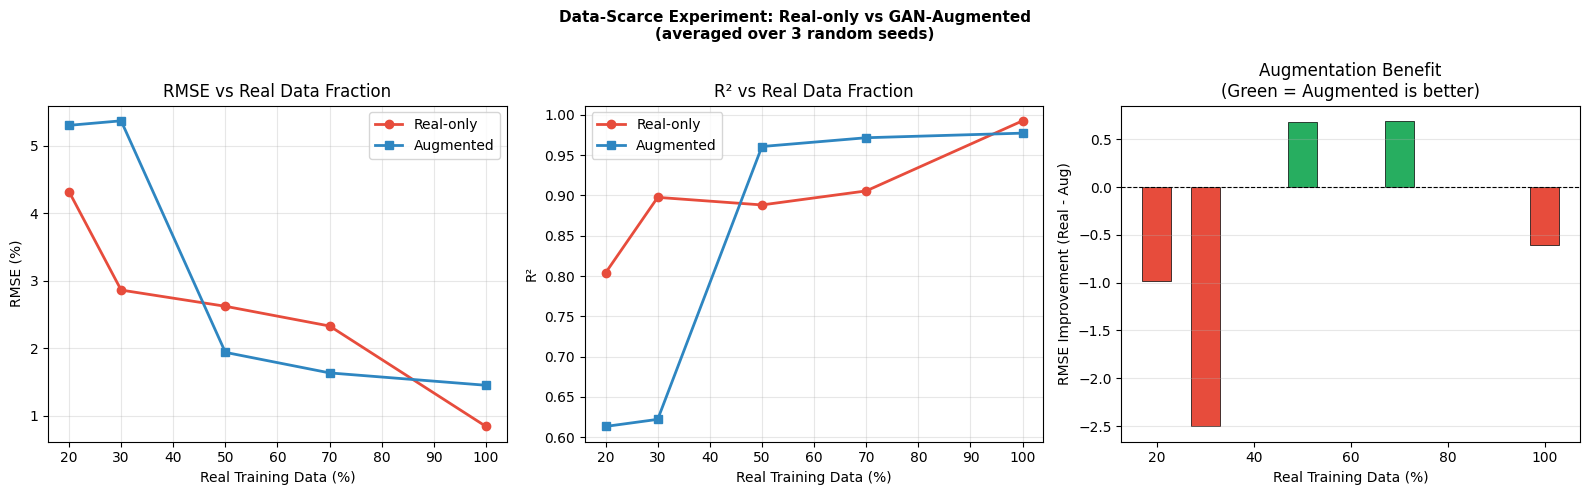

Figure saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fracs = results_df["Fraction (%)"].tolist()

# RMSE comparison
axes[0].plot(fracs, results_df["Real RMSE"], 'o-', color='#E74C3C', label='Real-only', lw=2)
axes[0].plot(fracs, results_df["Aug RMSE"],  's-', color='#2E86C1', label='Augmented', lw=2)
axes[0].set_xlabel("Real Training Data (%)")
axes[0].set_ylabel("RMSE (%)")
axes[0].set_title("RMSE vs Real Data Fraction")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# R² comparison
axes[1].plot(fracs, results_df["Real R2"], 'o-', color='#E74C3C', label='Real-only', lw=2)
axes[1].plot(fracs, results_df["Aug R2"],  's-', color='#2E86C1', label='Augmented', lw=2)
axes[1].set_xlabel("Real Training Data (%)")
axes[1].set_ylabel("R²")
axes[1].set_title("R² vs Real Data Fraction")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# RMSE Improvement (positive = aug is better)
colors_bar = ['#27AE60' if v > 0 else '#E74C3C' for v in results_df["RMSE Improvement"]]
axes[2].bar(fracs, results_df["RMSE Improvement"], color=colors_bar, width=6, edgecolor='black', lw=0.5)
axes[2].axhline(0, color='black', lw=0.8, linestyle='--')
axes[2].set_xlabel("Real Training Data (%)")
axes[2].set_ylabel("RMSE Improvement (Real - Aug)")
axes[2].set_title("Augmentation Benefit\n(Green = Augmented is better)")
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle("Data-Scarce Experiment: Real-only vs GAN-Augmented\n(averaged over 3 random seeds)",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "data_scarce_experiment.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 7. Save Results

In [7]:
results_df.to_csv(os.path.join(OUTPUT_DIR, "data_scarce_results.csv"), index=False)
print("Saved: data_scarce_results.csv")
print("Full results table:")
print(results_df.to_string(index=False))
print("Data-scarce experiment complete.")
print("Key takeaway:")
print("Look at RMSE Improvement at 20% and 30% fractions.")
print("Positive values = GAN augmentation helps when real data is scarce.")


Saved: data_scarce_results.csv
Full results table:
 Fraction (%)  Real Samples  Real RMSE  Real MAE  Real R2  Aug RMSE  Aug MAE  Aug R2  RMSE Improvement  R2 Improvement
           20           101     4.3187    3.3994   0.8039    5.2988   4.2672  0.6133           -0.9801         -0.1906
           30           152     2.8611    2.1118   0.8976    5.3656   4.4002  0.6221           -2.5045         -0.2755
           50           254     2.6210    2.0721   0.8882    1.9392   1.4171  0.9607            0.6818          0.0725
           70           355     2.3289    1.8754   0.9056    1.6351   1.2399  0.9716            0.6938          0.0660
          100           508     0.8429    0.6232   0.9926    1.4521   1.1957  0.9773           -0.6092         -0.0153
Data-scarce experiment complete.
Key takeaway:
Look at RMSE Improvement at 20% and 30% fractions.
Positive values = GAN augmentation helps when real data is scarce.
